# Alignment Debug Notebook

This notebook provides visual verification of the alignment results.
Use this to quickly check that time deltas are reasonable and alignment is working correctly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.style.use('default')  # Use matplotlib defaults (colorblind-friendly)

In [2]:
# First, let's see what experiments are available
print("Available aligned experiments:\n")

# Check for CSV directories (preferred format)
csv_dirs = sorted(Path('aligned_data').glob('*_csv'))
if csv_dirs:
    print("CSV format (recommended):")
    for d in csv_dirs:
        exp_name = d.name.replace('_csv', '').replace('_aligned', '')
        # Count files in directory
        num_files = len(list(d.glob('*.csv')))
        print(f"  - {exp_name} ({num_files} files)")

# Check for HDF5 files
h5_files = sorted(Path('aligned_data').glob('*.h5'))
if h5_files:
    print("\nHDF5 format:")
    for f in h5_files:
        exp_name = f.stem.replace('_aligned', '')
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  - {exp_name} ({size_mb:.1f} MB)")

print("\n" + "="*60)
print("Change 'experiment_name' in the next cell to analyze a different experiment")
print("="*60)

Available aligned experiments:

CSV format (recommended):
  - 007_Fast_stbd_turn_1 (6 files)
  - 016_Straight_cruise_1 (6 files)
  - 021_Quarter_turn_port (6 files)

HDF5 format:
  - 007_Fast_stbd_turn_1 (7.9 MB)
  - 016_Straight_cruise_1 (6.0 MB)
  - 021_Quarter_turn_port (3.9 MB)

Change 'experiment_name' in the next cell to analyze a different experiment


## Load Aligned Data

In [3]:
# Specify the experiment to analyze
experiment_name = '007_Fast_stbd_turn_1'  # Change this to analyze different experiments

# Define paths
aligned_file = Path(f'aligned_data/{experiment_name}_aligned.h5')
csv_dir = Path(f'aligned_data/{experiment_name}_csv')

# Storage for data
sensor_data = {}
metadata = None
store = None

# Prioritize CSV format since it's more compatible
if csv_dir.exists():
    print(f"Loading from CSV directory: {csv_dir}")
    print("Available files:")
    
    # Load sensor data
    for csv_file in sorted(csv_dir.glob('*.csv')):
        print(f"  - {csv_file.name}")
        if csv_file.stem != 'metadata':
            df = pd.read_csv(csv_file)
            sensor_data[csv_file.stem] = df
    
    # Load metadata if available
    metadata_file = csv_dir / 'metadata.csv'
    if metadata_file.exists():
        metadata = pd.read_csv(metadata_file)
    
    print(f"\nLoaded data for {len(sensor_data)} sensors:")
    for sensor_name, df in sensor_data.items():
        print(f"  {sensor_name}: {len(df)} samples")
        
elif aligned_file.exists():
    # Fallback to HDF5 if no CSV
    try:
        store = pd.HDFStore(str(aligned_file), mode='r')
        print(f"Loaded HDF5: {aligned_file}")
        for key in store.keys():
            if key != '/metadata':
                sensor_data[key.lstrip('/')] = store[key]
            else:
                metadata = store[key]
        print(f"Loaded {len(sensor_data)} sensors from HDF5")
    except Exception as e:
        print(f"Error loading HDF5: {e}")
        print("Please run export_to_csv.py to create CSV files")

else:
    print(f"No data found for experiment: {experiment_name}")
    print("\nAvailable experiments:")
    
    # Show available CSV directories
    csv_dirs = list(Path('aligned_data').glob('*_csv'))
    if csv_dirs:
        print("\nCSV format (recommended):")
        for d in sorted(csv_dirs):
            exp_name = d.name.replace('_csv', '').replace('_aligned', '')
            print(f"  - {exp_name}")
    
    # Show available HDF5 files
    h5_files = list(Path('aligned_data').glob('*.h5'))
    if h5_files:
        print("\nHDF5 format:")
        for f in sorted(h5_files):
            exp_name = f.stem.replace('_aligned', '')
            print(f"  - {exp_name}")

Loading from CSV directory: aligned_data\007_Fast_stbd_turn_1_csv
Available files:
  - gps.csv
  - metadata.csv
  - Sensor_3.csv
  - Sensor_4.csv
  - Sensor_5.csv
  - Sensor_wb.csv

Loaded data for 5 sensors:
  gps: 1070 samples
  Sensor_3: 26001 samples
  Sensor_4: 26000 samples
  Sensor_5: 26000 samples
  Sensor_wb: 12922 samples


In [4]:
# Display summary statistics for the loaded data
if sensor_data:
    print(f"Experiment: {experiment_name}")
    print(f"Data format: {'CSV' if csv_dir.exists() else 'HDF5'}")
    print(f"\nSensor Summary:")
    print("-" * 70)
    print(f"{'Sensor':<15} {'Samples':<10} {'Duration (s)':<15} {'Rate (Hz)':<10}")
    print("-" * 70)
    
    for sensor_name, df in sensor_data.items():
        # Determine time column
        time_col = 'aligned_time' if 'aligned_time' in df.columns else 'time_from_sync'
        
        if time_col in df.columns:
            duration = df[time_col].max() - df[time_col].min()
            rate = len(df) / duration if duration > 0 else 0
            print(f"{sensor_name:<15} {len(df):<10} {duration:<15.1f} {rate:<10.1f}")
    
    print("-" * 70)
    
    # Check alignment quality
    aligned_sensors = [s for s in sensor_data.keys() if 'time_diff_ms' in sensor_data[s].columns]
    if aligned_sensors:
        print(f"\nAlignment Quality (sensors with time_diff_ms):")
        for sensor in aligned_sensors:
            df = sensor_data[sensor]
            mean_diff = df['time_diff_ms'].mean()
            max_diff = df['time_diff_ms'].max()
            print(f"  {sensor}: mean={mean_diff:.3f}ms, max={max_diff:.3f}ms")
else:
    print("No data loaded!")

Experiment: 007_Fast_stbd_turn_1
Data format: CSV

Sensor Summary:
----------------------------------------------------------------------
Sensor          Samples    Duration (s)    Rate (Hz) 
----------------------------------------------------------------------
gps             1070       129.0           8.3       
Sensor_3        26001      130.0           200.0     
Sensor_4        26000      130.0           200.0     
Sensor_5        26000      130.0           200.0     
Sensor_wb       12922      130.0           99.4      
----------------------------------------------------------------------

Alignment Quality (sensors with time_diff_ms):
  gps: mean=10.308ms, max=20.000ms
  Sensor_4: mean=1.667ms, max=1.667ms
  Sensor_5: mean=1.667ms, max=1.667ms
  Sensor_wb: mean=2.570ms, max=3.333ms


## Check Alignment Metadata

In [5]:
# Load metadata
if metadata is not None:
    print("Alignment Metadata:")
    print(metadata.T)
else:
    print("No metadata available")

Alignment Metadata:
                                              0
reference_sensor                       Sensor_3
target_rate                                 200
num_sensors                                   5
alignment_timestamp  2025-06-18 12:18:36.055048


## Visualize Time Deltas

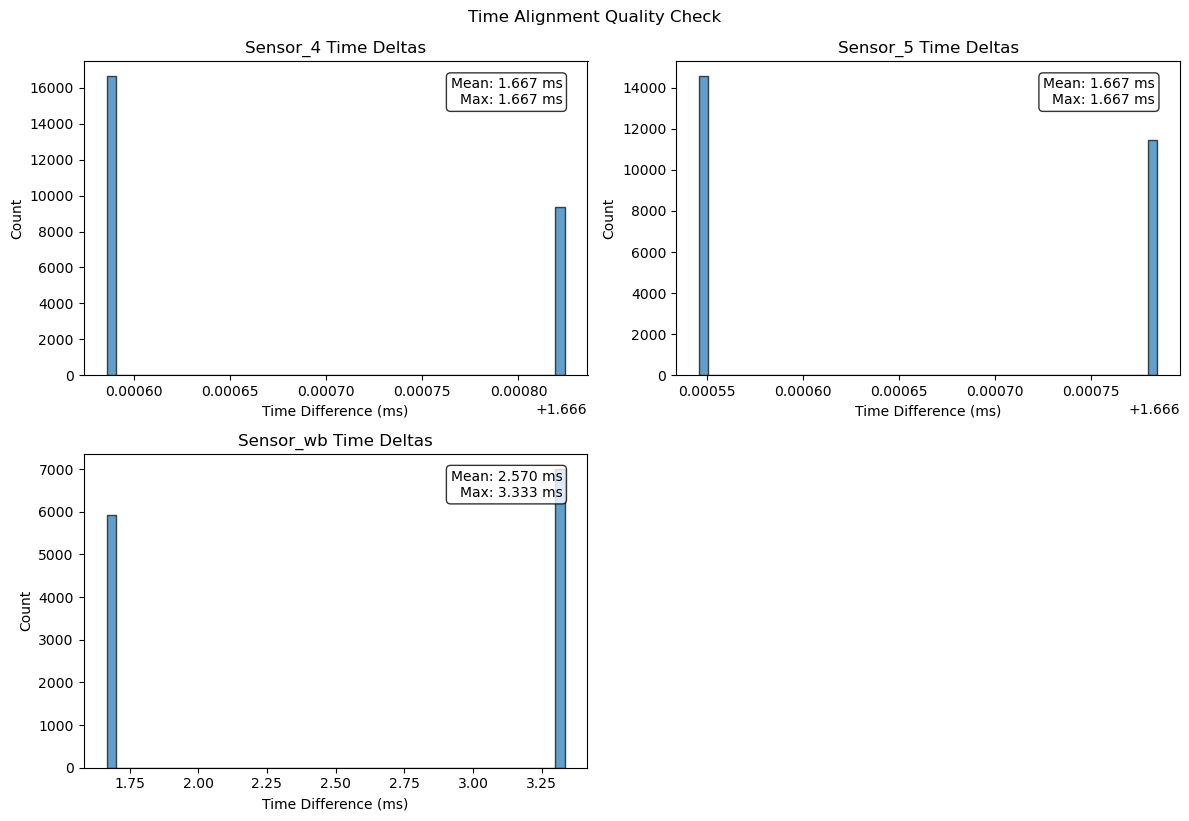

In [6]:
# Plot time differences for each aligned sensor
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

sensor_idx = 0
for sensor_name in ['Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_wb']:
    if sensor_name in sensor_data:
        df = sensor_data[sensor_name]
        
        if 'time_diff_ms' in df.columns:
            ax = axes[sensor_idx]
            
            # Plot histogram of time differences
            ax.hist(df['time_diff_ms'], bins=50, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Time Difference (ms)')
            ax.set_ylabel('Count')
            ax.set_title(f'{sensor_name} Time Deltas')
            
            # Add statistics
            mean_diff = df['time_diff_ms'].mean()
            max_diff = df['time_diff_ms'].max()
            ax.text(0.95, 0.95, f'Mean: {mean_diff:.3f} ms\nMax: {max_diff:.3f} ms',
                   transform=ax.transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            sensor_idx += 1

# Hide unused subplots
for i in range(sensor_idx, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.suptitle('Time Alignment Quality Check', y=1.02)
plt.show()

## Check Alignment Consistency Over Time

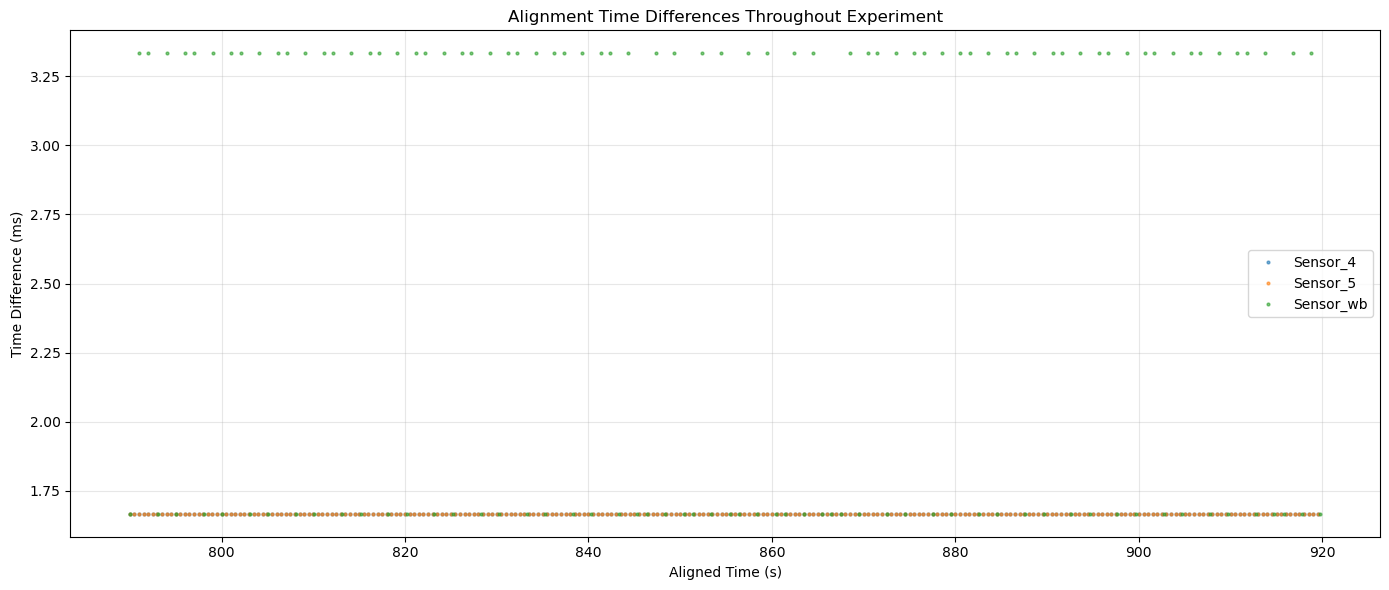

In [7]:
# Plot time differences over the duration of the experiment
plt.figure(figsize=(14, 6))

for sensor_name in ['Sensor_4', 'Sensor_5', 'Sensor_wb']:
    if sensor_name in sensor_data:
        df = sensor_data[sensor_name]
        
        if 'time_diff_ms' in df.columns and 'aligned_time' in df.columns:
            # Sample every 100th point to avoid overplotting
            sample_idx = slice(None, None, 100)
            plt.plot(df['aligned_time'].iloc[sample_idx], 
                    df['time_diff_ms'].iloc[sample_idx],
                    'o', markersize=2, alpha=0.6, label=sensor_name)

plt.xlabel('Aligned Time (s)')
plt.ylabel('Time Difference (ms)')
plt.title('Alignment Time Differences Throughout Experiment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sample Rate Verification

In [8]:
# Check actual sample rates after alignment
print("Effective Sample Rates After Alignment:\n")

for sensor_name, df in sensor_data.items():
    # Use 'time_from_sync' for reference sensor, 'aligned_time' for others
    time_col = 'aligned_time' if 'aligned_time' in df.columns else 'time_from_sync'
    
    if time_col in df.columns and len(df) > 1:
        # Calculate time differences between consecutive samples
        time_diffs = np.diff(df[time_col].values)
        
        # Filter out any large gaps
        valid_diffs = time_diffs[time_diffs < 0.1]  # Ignore gaps > 100ms
        
        if len(valid_diffs) > 0:
            mean_period = np.mean(valid_diffs)
            effective_rate = 1.0 / mean_period
            
            print(f"{sensor_name:12s}: {effective_rate:6.1f} Hz (period: {mean_period*1000:.2f} ms)")

Effective Sample Rates After Alignment:

gps         :  200.0 Hz (period: 5.00 ms)
Sensor_3    :  200.0 Hz (period: 5.00 ms)
Sensor_4    :  200.0 Hz (period: 5.00 ms)
Sensor_5    :  200.0 Hz (period: 5.00 ms)
Sensor_wb   :   99.4 Hz (period: 10.06 ms)


## Close the HDF5 Store

In [9]:
# Always close the store when done
if 'store' in locals() and store is not None:
    store.close()
    print("HDF5 store closed.")
else:
    print("No HDF5 store to close (using CSV data or no data loaded)")

No HDF5 store to close (using CSV data or no data loaded)
